# Домашнее задание 02. Обучение сверточных нейронных сетей на CIFAR-10

## Что нужно сдать

1. Заполненный ноутбук, где реализованы все блоки TODO.
2. Графики функции потерь и accuracy на train/validation для каждого эксперимента.
3. Таблицу с итоговыми метриками для всех экспериментов.
4. Короткий вывод: что помогло, что не помогло и почему.

## Правила

- Используйте только CIFAR-10.
- Не изменяйте трансформации для тестовой выборки.
- Во время отладки можно уменьшать число эпох, но финальные эксперименты должны обучаться достаточно долго, чтобы сравнение было осмысленным.
- Зафиксируйте random seed и опишите свое железо/среду выполнения.
- Не используйте готовые pretrained models: цель задания — самостоятельно реализовать и обучить небольшие CNN.


## Структура задания

Вам нужно выполнить пять частей:

1. Конвейер данных с разделением на train/validation.
2. Базовая CNN на основе семинара.
3. Улучшенная CNN с residual connections.
4. Эксперименты с обучением: аугментации, optimizer, scheduler и регуляризация.
5. Анализ ошибок: accuracy по классам, confusion matrix и примеры ошибок.

Когда нотбук будет завершен, мы ожидаем следующие выходные артефакты:

- 1 базовая модель.
- 1 улучшенная модель с residual connections.
- Не менее 3 контролируемых экспериментов, где за раз меняется только один фактор.
- Не менее 8-15 эпох на финальный эксперимент, в зависимости от вашего железа.


In [1]:
import os
import glob
import pickle
import random
import time
from dataclasses import dataclass, asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim import lr_scheduler
from torch.utils import data
from torchvision import datasets, transforms
from tqdm.auto import tqdm

try:
    from sklearn.metrics import confusion_matrix
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False

plt.rcParams["figure.figsize"] = (8, 4)


C:\ProgramData\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))


Устройство: cpu


# 1. Конвейер данных

На семинаре для обучения использовалась вся обучающая часть CIFAR-10. В этом домашнем задании нужно создать отдельную validation выборку. Тестовую выборку нужно использовать только один раз в конце.

TODO:

- Создайте `train_dataset_augmented` с обучающими аугментациями.
- Создайте `train_dataset_eval` с теми же training images, но без случайных аугментаций. Он понадобится для validation.
- Разделите индексы CIFAR-10 train part на train и validation subsets.
- Создайте `train_loader`, `val_loader`, `test_loader`.
- Проверьте размеры выборок и визуализируйте несколько augmented training images.

Важно: validation и test не должны использовать случайные трансформации, иначе метрики будут шумными и несравнимыми.


In [3]:
import kagglehub

# Скачиваем датасет CIFAR-10 с Kaggle. kagglehub кэширует загрузку, поэтому
# повторный вызов не будет каждый раз скачивать данные заново.
KAGGLE_DATASET_PATH = kagglehub.dataset_download("ayush1220/cifar10")
print("Path to dataset files:", KAGGLE_DATASET_PATH)

DATA_ROOT = Path("cifar10")
NUM_CLASSES = 10
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

train_batch_size = 128
test_batch_size = 256
validation_fraction = 0.1
num_workers = 2

# Статистики каналов CIFAR-10. Обычно лучше использовать статистики датасета, а не нормализацию на 0.5.
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

train_transforms = transforms.Compose([
    # Разумные, не слишком агрессивные аугментации для CIFAR-10.
    transforms.RandomCrop(32, padding=4, padding_mode="reflect"),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

eval_transforms = transforms.Compose([
    # Не добавляйте сюда случайные аугментации.
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])


Path to dataset files: C:\Users\kiril\.cache\kagglehub\datasets\ayush1220\cifar10\versions\2


In [4]:
class ArrayCIFAR10(data.Dataset):
    """CIFAR-10 в виде numpy-массива изображений. Совместим с data.Subset и DataLoader."""

    def __init__(self, images, labels, transform=None):
        # images: uint8 array формы (N, 32, 32, 3)
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx])
        label = int(self.labels[idx])
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def _unpickle(file_path):
    with open(file_path, "rb") as f:
        return pickle.load(f, encoding="bytes")


def _find_dir_containing(base_path, filename_prefix):
    for root, _, files in os.walk(base_path):
        if any(name.startswith(filename_prefix) for name in files):
            return root
    return None


def _find_imagefolder_dirs(base_path):
    train_dir, test_dir = None, None
    for root, dirs, _ in os.walk(base_path):
        lower_to_orig = {d.lower(): d for d in dirs}
        if train_dir is None and "train" in lower_to_orig:
            candidate = os.path.join(root, lower_to_orig["train"])
            if any(os.path.isdir(os.path.join(candidate, d)) for d in os.listdir(candidate)):
                train_dir = candidate
        if test_dir is None and ("test" in lower_to_orig or "val" in lower_to_orig):
            key = "test" if "test" in lower_to_orig else "val"
            candidate = os.path.join(root, lower_to_orig[key])
            if any(os.path.isdir(os.path.join(candidate, d)) for d in os.listdir(candidate)):
                test_dir = candidate
    return train_dir, test_dir


def _load_pickled_cifar10(batches_dir):
    train_files = sorted(glob.glob(os.path.join(batches_dir, "data_batch_*")))
    test_files = glob.glob(os.path.join(batches_dir, "test_batch*"))
    if not train_files or not test_files:
        return None

    train_images_list, train_labels_list = [], []
    for file_path in train_files:
        entry = _unpickle(file_path)
        train_images_list.append(entry[b"data"])
        train_labels_list.extend(entry.get(b"labels", entry.get(b"fine_labels")))
    train_images = np.concatenate(train_images_list, axis=0)
    train_images = train_images.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    train_labels = np.array(train_labels_list)

    test_entry = _unpickle(test_files[0])
    test_images = test_entry[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    test_labels = np.array(test_entry.get(b"labels", test_entry.get(b"fine_labels")))

    return train_images, train_labels, test_images, test_labels


def build_cifar10_datasets(kaggle_path, train_transform, eval_transform):
    """Строит train_dataset_augmented, train_dataset_eval, test_dataset из данных kagglehub.

    Поддерживает два распространенных варианта раскладки CIFAR-10 на Kaggle:
      1. Официальный pickled формат (data_batch_1..5, test_batch).
      2. ImageFolder формат (train/<class>/*.png, test/<class>/*.png).
    Если ни один вариант не найден, датасет скачивается напрямую через torchvision
    (нужен доступ в интернет), чтобы код гарантированно отработал.
    """
    batches_dir = _find_dir_containing(kaggle_path, "data_batch_1")
    if batches_dir is not None:
        loaded = _load_pickled_cifar10(batches_dir)
        if loaded is not None:
            train_images, train_labels, test_images, test_labels = loaded
            print(f"Найден pickled CIFAR-10 в: {batches_dir}")
            return (
                ArrayCIFAR10(train_images, train_labels, transform=train_transform),
                ArrayCIFAR10(train_images, train_labels, transform=eval_transform),
                ArrayCIFAR10(test_images, test_labels, transform=eval_transform),
            )

    train_dir, test_dir = _find_imagefolder_dirs(kaggle_path)
    if train_dir is not None and test_dir is not None:
        print(f"Найден ImageFolder CIFAR-10: train={train_dir}, test={test_dir}")
        return (
            datasets.ImageFolder(train_dir, transform=train_transform),
            datasets.ImageFolder(train_dir, transform=eval_transform),
            datasets.ImageFolder(test_dir, transform=eval_transform),
        )

    print("Не удалось распознать структуру датасета из kagglehub, "
          "скачиваю официальный CIFAR-10 через torchvision (нужен интернет).")
    return (
        datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=True, transform=train_transform),
        datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=True, transform=eval_transform),
        datasets.CIFAR10(root=str(DATA_ROOT), train=False, download=True, transform=eval_transform),
    )


train_dataset_augmented, train_dataset_eval, test_dataset = build_cifar10_datasets(
    KAGGLE_DATASET_PATH, train_transforms, eval_transforms
)

num_train_total = len(train_dataset_augmented)
rng = np.random.RandomState(42)
shuffled_indices = rng.permutation(num_train_total)
num_val = int(num_train_total * validation_fraction)

val_indices = shuffled_indices[:num_val]
train_indices = shuffled_indices[num_val:]

train_subset = data.Subset(train_dataset_augmented, train_indices)
val_subset = data.Subset(train_dataset_eval, val_indices)

pin_memory = torch.cuda.is_available()

train_loader = data.DataLoader(
    train_subset, batch_size=train_batch_size, shuffle=True,
    num_workers=num_workers, pin_memory=pin_memory, drop_last=True,
)
val_loader = data.DataLoader(
    val_subset, batch_size=test_batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=pin_memory,
)
test_loader = data.DataLoader(
    test_dataset, batch_size=test_batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=pin_memory,
)

print(f"Train: {len(train_subset)}, Validation: {len(val_subset)}, Test: {len(test_dataset)}")
assert len(train_subset) + len(val_subset) == num_train_total, "train + validation должно равняться размеру train part"


Найден ImageFolder CIFAR-10: train=C:\Users\kiril\.cache\kagglehub\datasets\ayush1220\cifar10\versions\2\cifar10\train, test=C:\Users\kiril\.cache\kagglehub\datasets\ayush1220\cifar10\versions\2\cifar10\test
Train: 45000, Validation: 5000, Test: 10000


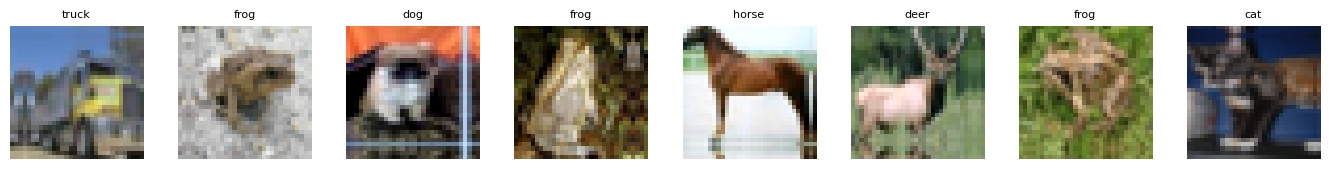

In [5]:
def denormalize(images, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    mean = torch.tensor(mean).view(1, 3, 1, 1)
    std = torch.tensor(std).view(1, 3, 1, 1)
    return images.cpu() * std + mean


def show_batch(loader, n=8):
    images, labels = next(iter(loader))
    images = denormalize(images[:n]).clamp(0, 1)
    fig, axs = plt.subplots(1, n, figsize=(1.7 * n, 1.7))
    for ax, image, label in zip(axs, images, labels[:n]):
        ax.imshow(image.permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[int(label)], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_loader, n=8)


# 2. Утилиты для обучения

На семинаре использовались отдельные функции `train` и `test`. Здесь вы расширите их так, чтобы каждая эпоха возвращала метрики, которые можно строить на графиках и сравнивать.

TODO:

- Реализуйте подсчет accuracy по logits.
- Реализуйте `run_one_epoch`: она должна работать и для train, и для evaluation режима.
- Убедитесь, что loss усредняется по объектам, а не только по batch.
- Реализуйте выбор optimizer и scheduler по `ExperimentConfig`.
- Реализуйте `fit`: цикл по эпохам, scheduler step, сохранение лучшей модели по validation accuracy и историю метрик.

Ожидаемый формат history: список словарей с ключами `epoch`, `lr`, `train_loss`, `train_accuracy`, `val_loss`, `val_accuracy`.


In [6]:
@dataclass
class ExperimentConfig:
    name: str
    epochs: int = 10
    lr: float = 1e-3
    weight_decay: float = 0.0
    optimizer: str = "adam"  # adam или sgd
    scheduler: str = "none"  # none, step, cosine, plateau


def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    correct = (preds == targets).sum()
    return correct.item()


def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    grad_context = torch.enable_grad() if is_train else torch.no_grad()
    with grad_context:
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            batch_size = images.size(0)

            if is_train:
                optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, targets)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * batch_size
            total_correct += accuracy_from_logits(logits, targets)
            total_samples += batch_size

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
    }


def make_optimizer(model, config: ExperimentConfig):
    if config.optimizer == "adam":
        return Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    elif config.optimizer == "sgd":
        return SGD(model.parameters(), lr=config.lr, momentum=0.9, weight_decay=config.weight_decay)
    else:
        raise ValueError(f"Неизвестный optimizer: {config.optimizer}")


def make_scheduler(optimizer, config: ExperimentConfig):
    if config.scheduler == "none":
        return None
    elif config.scheduler == "step":
        step_size = max(config.epochs // 3, 1)
        return lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=0.1)
    elif config.scheduler == "cosine":
        return lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs)
    elif config.scheduler == "plateau":
        return lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    else:
        raise ValueError(f"Неизвестный scheduler: {config.scheduler}")


In [7]:
def fit(model, config: ExperimentConfig, train_loader, val_loader):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model, config)
    scheduler = make_scheduler(optimizer, config)

    history = []
    best_val_accuracy = -1.0
    best_state_dict = None
    start_time = time.time()

    for epoch in range(1, config.epochs + 1):
        train_metrics = run_one_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_one_epoch(model, val_loader, criterion, optimizer=None)

        current_lr = optimizer.param_groups[0]["lr"]

        if scheduler is not None:
            if isinstance(scheduler, lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_metrics["loss"])
            else:
                scheduler.step()

        history.append({
            "epoch": epoch,
            "lr": current_lr,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
        })

        if val_metrics["accuracy"] > best_val_accuracy:
            best_val_accuracy = val_metrics["accuracy"]
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"[{config.name}] epoch {epoch:02d}/{config.epochs} "
            f"lr={current_lr:.2e} "
            f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['accuracy']:.4f} "
            f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['accuracy']:.4f}"
        )

    elapsed_sec = time.time() - start_time

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    summary = {
        "name": config.name,
        "optimizer": config.optimizer,
        "scheduler": config.scheduler,
        "lr": config.lr,
        "weight_decay": config.weight_decay,
        "epochs": config.epochs,
        "best_val_accuracy": best_val_accuracy,
        "elapsed_sec": elapsed_sec,
    }

    return model, history, summary


In [8]:
def plot_history(history, title="История обучения"):
    epochs = [row["epoch"] for row in history]
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].plot(epochs, [row["train_loss"] for row in history], label="train")
    axs[0].plot(epochs, [row["val_loss"] for row in history], label="validation")
    axs[0].set_title("Loss")
    axs[0].set_xlabel("Эпоха")
    axs[0].legend()

    axs[1].plot(epochs, [row["train_accuracy"] for row in history], label="train")
    axs[1].plot(epochs, [row["val_accuracy"] for row in history], label="validation")
    axs[1].set_title("Accuracy")
    axs[1].set_xlabel("Эпоха")
    axs[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# 3. Базовая модель

Воспроизведите модель из семинара как baseline, но внесите две важные правки:

- Возвращайте сырые logits из `forward`; `nn.CrossEntropyLoss` уже применяет log-softmax внутри.
- Применяйте dropout перед финальным выходом классификатора, а не после него.

TODO:

- Реализуйте baseline model.
- Проверьте размерность выхода на случайном batch: ожидается `[batch_size, 10]`.
- Обучите модель.
- Постройте train/validation curves.

Подсказка по размерностям: если использовать conv layers без padding, как на семинаре, после трех сверточных блоков размер может стать `64 * 11 * 11`. Проверьте это самостоятельно через print shape или dummy forward pass.


In [9]:
class BaselineCNN(nn.Module):
    def __init__(self, dropout_conv=0.25, dropout_fc=0.1):
        super().__init__()
        self.features = nn.Sequential(
            # Блок 1: 32x32 -> conv(k3, no pad) -> 30x30 -> maxpool(2) -> 15x15
            nn.Conv2d(3, 16, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.BatchNorm2d(16),

            # Блок 2: 15x15 -> conv(k3, no pad) -> 13x13
            nn.Conv2d(16, 32, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(32),
            nn.Dropout2d(dropout_conv),

            # Блок 3: 13x13 -> conv(k3, no pad) -> 11x11
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 11 * 11, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_fc),
            nn.Linear(128, NUM_CLASSES),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


baseline = BaselineCNN()
dummy = torch.randn(4, 3, 32, 32)
print(baseline(dummy).shape)  # ожидается torch.Size([4, 10])
print(baseline)


torch.Size([4, 10])
BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU(inplace=True)
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (9): ReLU(inplace=True)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=7744, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=10, 

[baseline] epoch 01/10 lr=1.00e-03 train_loss=1.5665 train_acc=0.4364 val_loss=1.1783 val_acc=0.5798
[baseline] epoch 02/10 lr=1.00e-03 train_loss=1.2677 train_acc=0.5468 val_loss=0.9700 val_acc=0.6470
[baseline] epoch 03/10 lr=1.00e-03 train_loss=1.1512 train_acc=0.5871 val_loss=0.8873 val_acc=0.6884
[baseline] epoch 04/10 lr=1.00e-03 train_loss=1.0829 train_acc=0.6151 val_loss=0.8531 val_acc=0.6940
[baseline] epoch 05/10 lr=1.00e-03 train_loss=1.0232 train_acc=0.6370 val_loss=0.7981 val_acc=0.7196
[baseline] epoch 06/10 lr=1.00e-03 train_loss=0.9874 train_acc=0.6514 val_loss=0.7786 val_acc=0.7210
[baseline] epoch 07/10 lr=1.00e-03 train_loss=0.9574 train_acc=0.6640 val_loss=0.7642 val_acc=0.7346
[baseline] epoch 08/10 lr=1.00e-03 train_loss=0.9407 train_acc=0.6689 val_loss=0.7460 val_acc=0.7352
[baseline] epoch 09/10 lr=1.00e-03 train_loss=0.9086 train_acc=0.6793 val_loss=0.7272 val_acc=0.7468
[baseline] epoch 10/10 lr=1.00e-03 train_loss=0.8909 train_acc=0.6881 val_loss=0.7391 val_a

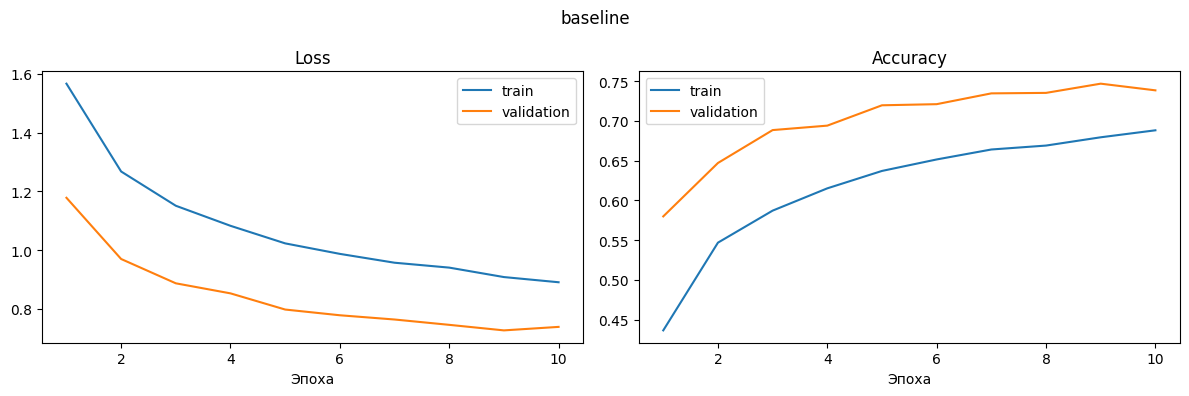

{'name': 'baseline',
 'optimizer': 'adam',
 'scheduler': 'plateau',
 'lr': 0.001,
 'weight_decay': 0.0,
 'epochs': 10,
 'best_val_accuracy': 0.7468,
 'elapsed_sec': 1505.1460554599762}

In [10]:
baseline_config = ExperimentConfig(
    name="baseline",
    epochs=10,  # для финального прогона: 10-15 эпох в зависимости от железа
    lr=1e-3,
    weight_decay=0.0,
    optimizer="adam",
    scheduler="plateau",
)

baseline_model, baseline_history, baseline_summary = fit(baseline, baseline_config, train_loader, val_loader)
plot_history(baseline_history, baseline_config.name)
baseline_summary


# 4. Улучшенная модель

Теперь спроектируйте более сильную CNN с residual connections. Она все еще должна быть достаточно небольшой, чтобы обучаться на CIFAR-10 за разумное время.

Требования:

- Не менее 4 сверточных слоев.
- BatchNorm или другой метод нормализации.
- Не менее одной операции downsampling.
- Global average pooling или хорошо обоснованная fully connected head.
- Dropout или weight decay.
- Residual connections: используйте shortcut-соединения внутри сверточных блоков.

TODO:

- Реализуйте `ResidualBlock`.
- Внутри блока сделайте main path из двух сверточных слоев `3x3`.
- Реализуйте shortcut path:
  - если `stride == 1` и число каналов не меняется, используйте `nn.Identity()`;
  - иначе используйте `1x1 Conv2d` со stride и `BatchNorm2d`, чтобы привести форму shortcut к форме main path.
- В `forward` сложите main path и shortcut, затем примените ReLU.
- Соберите `ImprovedCNN` из нескольких residual blocks и `AdaptiveAvgPool2d((1, 1))`.
- Проверьте, что выход модели имеет размер `[batch_size, 10]`.


In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Если меняются spatial size или число каналов, приводим shortcut к нужной форме.
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out, inplace=True)
        out = self.dropout(out)
        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = F.relu(out, inplace=True)
        return out


class ImprovedCNN(nn.Module):
    def __init__(self, width=32, dropout=0.1):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, width),
            ResidualBlock(width, width, dropout=dropout),
            ResidualBlock(width, width * 2, stride=2, dropout=dropout),   # downsampling
            ResidualBlock(width * 2, width * 2, dropout=dropout),
            ResidualBlock(width * 2, width * 4, stride=2, dropout=dropout),  # downsampling
            ResidualBlock(width * 4, width * 4, dropout=dropout),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(width * 4, NUM_CLASSES)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


improved = ImprovedCNN(width=32, dropout=0.1)
dummy = torch.randn(4, 3, 32, 32)
print(improved(dummy).shape)  # ожидается torch.Size([4, 10])
print("Параметры:", sum(p.numel() for p in improved.parameters() if p.requires_grad))


torch.Size([4, 10])
Параметры: 678058


[improved_cnn] epoch 01/12 lr=1.00e-03 train_loss=1.5206 train_acc=0.4369 val_loss=1.5076 val_acc=0.4758
[improved_cnn] epoch 02/12 lr=9.83e-04 train_loss=1.1175 train_acc=0.5978 val_loss=0.9257 val_acc=0.6674
[improved_cnn] epoch 03/12 lr=9.33e-04 train_loss=0.9453 train_acc=0.6640 val_loss=0.8031 val_acc=0.7120
[improved_cnn] epoch 04/12 lr=8.54e-04 train_loss=0.8283 train_acc=0.7087 val_loss=0.8183 val_acc=0.7146
[improved_cnn] epoch 05/12 lr=7.50e-04 train_loss=0.7415 train_acc=0.7401 val_loss=0.6147 val_acc=0.7854
[improved_cnn] epoch 06/12 lr=6.29e-04 train_loss=0.6719 train_acc=0.7658 val_loss=0.6089 val_acc=0.7908
[improved_cnn] epoch 07/12 lr=5.00e-04 train_loss=0.6183 train_acc=0.7869 val_loss=0.5151 val_acc=0.8202
[improved_cnn] epoch 08/12 lr=3.71e-04 train_loss=0.5692 train_acc=0.8048 val_loss=0.4850 val_acc=0.8386
[improved_cnn] epoch 09/12 lr=2.50e-04 train_loss=0.5270 train_acc=0.8192 val_loss=0.4628 val_acc=0.8396
[improved_cnn] epoch 10/12 lr=1.46e-04 train_loss=0.499

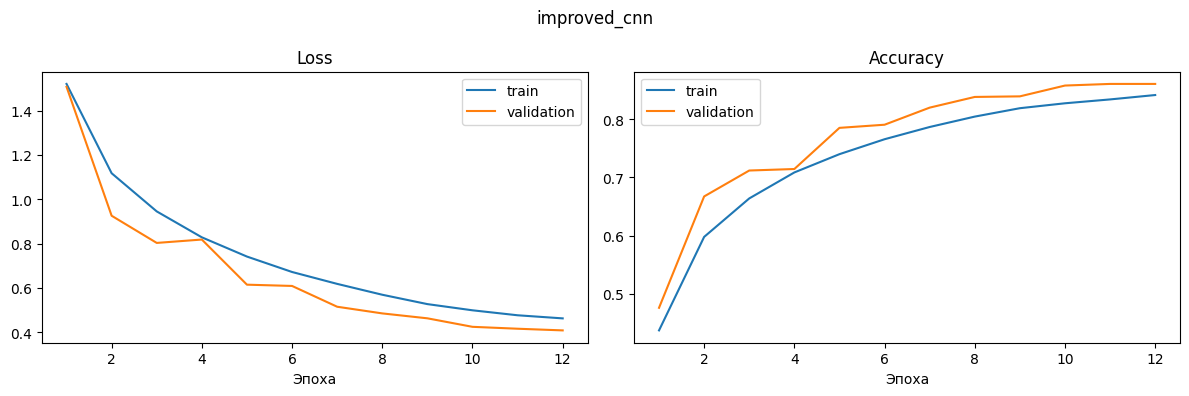

{'name': 'improved_cnn',
 'optimizer': 'adam',
 'scheduler': 'cosine',
 'lr': 0.001,
 'weight_decay': 0.0001,
 'epochs': 12,
 'best_val_accuracy': 0.861,
 'elapsed_sec': 3390.609139919281}

In [12]:
improved_config = ExperimentConfig(
    name="improved_cnn",
    epochs=12,
    lr=1e-3,
    weight_decay=1e-4,
    optimizer="adam",
    scheduler="cosine",
)

improved_model, improved_history, improved_summary = fit(improved, improved_config, train_loader, val_loader)
plot_history(improved_history, improved_config.name)
improved_summary


# 5. Контролируемые эксперименты

Запустите не менее трех контролируемых экспериментов. Меняйте только один фактор за раз, а остальные настройки сохраняйте максимально похожими.

Примеры:

- Без аугментаций vs. слабые аугментации vs. более сильные аугментации.
- Adam vs. SGD with momentum.
- Без scheduler vs. StepLR vs. CosineAnnealingLR.
- Значения dropout: 0, 0.1, 0.3.
- Weight decay: 0, 1e-4, 5e-4.
- Ширина модели: 16, 32, 64.

TODO:

- Определите конфиги экспериментов.
- Обучите модели.
- Сохраните histories и summaries.
- Постройте таблицу результатов.


=== Эксперимент: exp_control ===
[exp_control] epoch 01/10 lr=1.00e-03 train_loss=1.4956 train_acc=0.4513 val_loss=1.1225 val_acc=0.5986
[exp_control] epoch 02/10 lr=9.76e-04 train_loss=1.1039 train_acc=0.6039 val_loss=0.9409 val_acc=0.6686
[exp_control] epoch 03/10 lr=9.05e-04 train_loss=0.9496 train_acc=0.6621 val_loss=0.8991 val_acc=0.6970
[exp_control] epoch 04/10 lr=7.94e-04 train_loss=0.8389 train_acc=0.7018 val_loss=0.7367 val_acc=0.7486
[exp_control] epoch 05/10 lr=6.55e-04 train_loss=0.7498 train_acc=0.7346 val_loss=0.6528 val_acc=0.7782
[exp_control] epoch 06/10 lr=5.00e-04 train_loss=0.6751 train_acc=0.7630 val_loss=0.6375 val_acc=0.7796
[exp_control] epoch 07/10 lr=3.45e-04 train_loss=0.6205 train_acc=0.7839 val_loss=0.5237 val_acc=0.8202
[exp_control] epoch 08/10 lr=2.06e-04 train_loss=0.5782 train_acc=0.7978 val_loss=0.5220 val_acc=0.8256
[exp_control] epoch 09/10 lr=9.55e-05 train_loss=0.5487 train_acc=0.8092 val_loss=0.4802 val_acc=0.8382
[exp_control] epoch 10/10 lr=2.

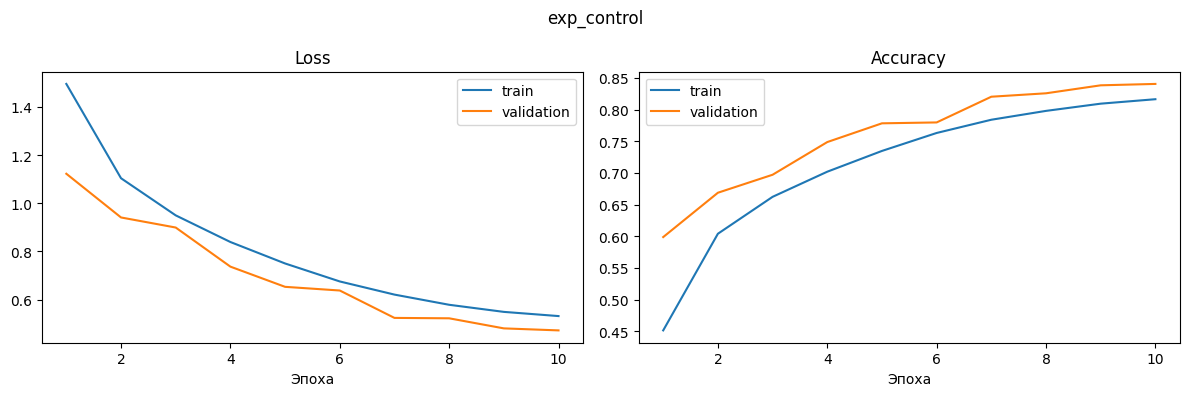

=== Эксперимент: exp_optimizer_sgd ===
[exp_optimizer_sgd] epoch 01/10 lr=1.00e-03 train_loss=1.8951 train_acc=0.2904 val_loss=1.6348 val_acc=0.3954
[exp_optimizer_sgd] epoch 02/10 lr=9.76e-04 train_loss=1.6284 train_acc=0.3983 val_loss=1.4482 val_acc=0.4784
[exp_optimizer_sgd] epoch 03/10 lr=9.05e-04 train_loss=1.5151 train_acc=0.4438 val_loss=1.3605 val_acc=0.5000
[exp_optimizer_sgd] epoch 04/10 lr=7.94e-04 train_loss=1.4286 train_acc=0.4766 val_loss=1.2656 val_acc=0.5466
[exp_optimizer_sgd] epoch 05/10 lr=6.55e-04 train_loss=1.3686 train_acc=0.5037 val_loss=1.2171 val_acc=0.5718
[exp_optimizer_sgd] epoch 06/10 lr=5.00e-04 train_loss=1.3155 train_acc=0.5236 val_loss=1.1595 val_acc=0.5898
[exp_optimizer_sgd] epoch 07/10 lr=3.45e-04 train_loss=1.2790 train_acc=0.5390 val_loss=1.1279 val_acc=0.5980
[exp_optimizer_sgd] epoch 08/10 lr=2.06e-04 train_loss=1.2519 train_acc=0.5464 val_loss=1.1069 val_acc=0.6010
[exp_optimizer_sgd] epoch 09/10 lr=9.55e-05 train_loss=1.2377 train_acc=0.5534 va

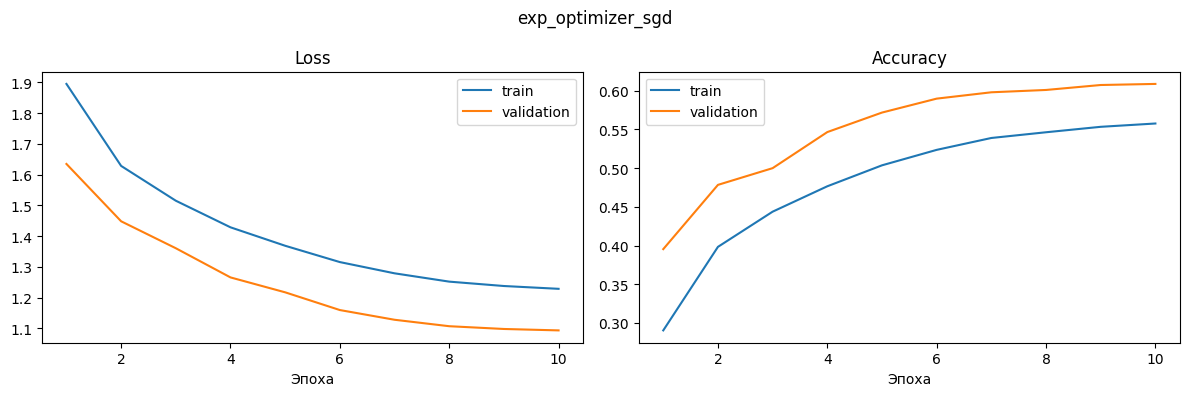

=== Эксперимент: exp_scheduler_none ===
[exp_scheduler_none] epoch 01/10 lr=1.00e-03 train_loss=1.4956 train_acc=0.4513 val_loss=1.1225 val_acc=0.5986
[exp_scheduler_none] epoch 02/10 lr=1.00e-03 train_loss=1.1047 train_acc=0.6028 val_loss=0.9375 val_acc=0.6694
[exp_scheduler_none] epoch 03/10 lr=1.00e-03 train_loss=0.9540 train_acc=0.6616 val_loss=0.9013 val_acc=0.6948
[exp_scheduler_none] epoch 04/10 lr=1.00e-03 train_loss=0.8479 train_acc=0.6974 val_loss=0.7704 val_acc=0.7398
[exp_scheduler_none] epoch 05/10 lr=1.00e-03 train_loss=0.7653 train_acc=0.7299 val_loss=0.6605 val_acc=0.7706
[exp_scheduler_none] epoch 06/10 lr=1.00e-03 train_loss=0.6962 train_acc=0.7545 val_loss=0.6786 val_acc=0.7656
[exp_scheduler_none] epoch 07/10 lr=1.00e-03 train_loss=0.6445 train_acc=0.7767 val_loss=0.5899 val_acc=0.7970
[exp_scheduler_none] epoch 08/10 lr=1.00e-03 train_loss=0.6083 train_acc=0.7883 val_loss=0.5447 val_acc=0.8122
[exp_scheduler_none] epoch 09/10 lr=1.00e-03 train_loss=0.5731 train_acc

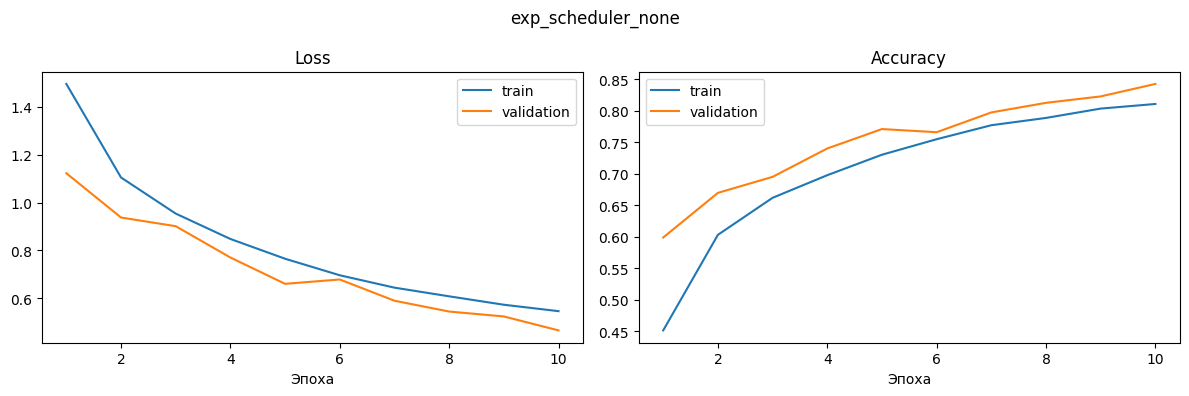

=== Эксперимент: exp_weight_decay_1e4 ===
[exp_weight_decay_1e4] epoch 01/10 lr=1.00e-03 train_loss=1.4953 train_acc=0.4516 val_loss=1.1204 val_acc=0.5998
[exp_weight_decay_1e4] epoch 02/10 lr=9.76e-04 train_loss=1.1049 train_acc=0.6042 val_loss=0.9375 val_acc=0.6696
[exp_weight_decay_1e4] epoch 03/10 lr=9.05e-04 train_loss=0.9478 train_acc=0.6640 val_loss=0.9003 val_acc=0.6978
[exp_weight_decay_1e4] epoch 04/10 lr=7.94e-04 train_loss=0.8358 train_acc=0.7033 val_loss=0.7937 val_acc=0.7326
[exp_weight_decay_1e4] epoch 05/10 lr=6.55e-04 train_loss=0.7510 train_acc=0.7356 val_loss=0.6269 val_acc=0.7796
[exp_weight_decay_1e4] epoch 06/10 lr=5.00e-04 train_loss=0.6751 train_acc=0.7639 val_loss=0.6322 val_acc=0.7832
[exp_weight_decay_1e4] epoch 07/10 lr=3.45e-04 train_loss=0.6190 train_acc=0.7850 val_loss=0.5246 val_acc=0.8162
[exp_weight_decay_1e4] epoch 08/10 lr=2.06e-04 train_loss=0.5732 train_acc=0.8005 val_loss=0.5213 val_acc=0.8210
[exp_weight_decay_1e4] epoch 09/10 lr=9.55e-05 train_l

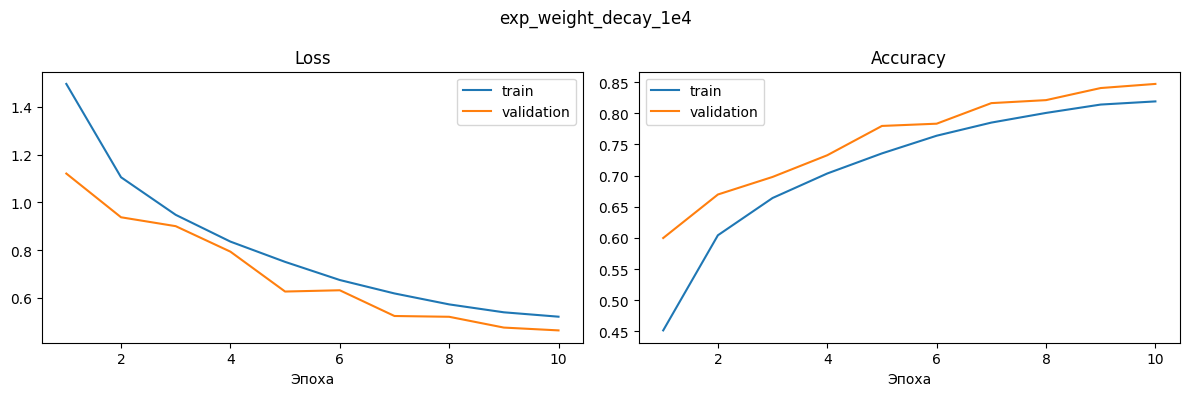

In [13]:
# Контролируемые эксперименты: каждый следующий конфиг меняет ровно один фактор
# относительно "контрольного" эксперимента exp_control.

experiments = [
    ExperimentConfig(name="exp_control", epochs=10, lr=1e-3, weight_decay=0.0, optimizer="adam", scheduler="cosine"),
    ExperimentConfig(name="exp_optimizer_sgd", epochs=10, lr=1e-3, weight_decay=0.0, optimizer="sgd", scheduler="cosine"),
    ExperimentConfig(name="exp_scheduler_none", epochs=10, lr=1e-3, weight_decay=0.0, optimizer="adam", scheduler="none"),
    ExperimentConfig(name="exp_weight_decay_1e4", epochs=10, lr=1e-3, weight_decay=1e-4, optimizer="adam", scheduler="cosine"),
]

# Собираем результаты baseline и improved моделей вместе с результатами экспериментов,
# чтобы финальный выбор "лучшей модели" учитывал все обученные модели.
all_histories = {"baseline": baseline_history, "improved_cnn": improved_history}
all_summaries = {"baseline": baseline_summary, "improved_cnn": improved_summary}
trained_models = {"baseline": baseline_model, "improved_cnn": improved_model}

for config in experiments:
    print(f"=== Эксперимент: {config.name} ===")
    seed_everything(42)
    model = ImprovedCNN(width=32, dropout=0.1)
    trained_model, history, summary = fit(model, config, train_loader, val_loader)

    all_histories[config.name] = history
    all_summaries[config.name] = summary
    trained_models[config.name] = trained_model

    plot_history(history, config.name)


In [14]:
def print_results_table(summaries):
    if not summaries:
        print("Результатов экспериментов пока нет.")
        return
    keys = ["name", "optimizer", "scheduler", "lr", "weight_decay", "epochs", "best_val_accuracy", "elapsed_sec"]
    header = " | ".join(keys)
    print(header)
    print("-" * len(header))
    for summary in summaries.values():
        row = []
        for key in keys:
            value = summary.get(key, "")
            if isinstance(value, float):
                value = f"{value:.4f}"
            row.append(str(value))
        print(" | ".join(row))

print_results_table(all_summaries)


name | optimizer | scheduler | lr | weight_decay | epochs | best_val_accuracy | elapsed_sec
-------------------------------------------------------------------------------------------
baseline | adam | plateau | 0.0010 | 0.0000 | 10 | 0.7468 | 1505.1461
improved_cnn | adam | cosine | 0.0010 | 0.0001 | 12 | 0.8610 | 3390.6091
exp_control | adam | cosine | 0.0010 | 0.0000 | 10 | 0.8404 | 2673.4402
exp_optimizer_sgd | sgd | cosine | 0.0010 | 0.0000 | 10 | 0.6088 | 2835.4595
exp_scheduler_none | adam | none | 0.0010 | 0.0000 | 10 | 0.8422 | 3024.1635
exp_weight_decay_1e4 | adam | cosine | 0.0010 | 0.0001 | 10 | 0.8470 | 2855.4432


# 6. Финальная оценка на test

Выберите лучшую модель, используя только validation accuracy. Затем оцените эту модель на test set один раз.

TODO:

- Найдите имя лучшего эксперимента по `best_val_accuracy`.
- Достаньте соответствующую модель из `trained_models`.
- Посчитайте test loss и test accuracy через `run_one_epoch` без optimizer.
- Укажите точное имя эксперимента и финальный test score.

Важно: test set нельзя использовать для выбора гиперпараметров. Он нужен только для финальной честной оценки.


In [15]:
best_name = max(all_summaries, key=lambda name: all_summaries[name]["best_val_accuracy"])
best_model = trained_models[best_name].to(device)

test_metrics = run_one_epoch(best_model, test_loader, nn.CrossEntropyLoss(), optimizer=None)

print(f"Лучший эксперимент по validation accuracy: {best_name}")
print(f"Best validation accuracy: {all_summaries[best_name]['best_val_accuracy']:.4f}")
print(f"Test loss: {test_metrics['loss']:.4f}")
print(f"Test accuracy: {test_metrics['accuracy']:.4f}")


Лучший эксперимент по validation accuracy: improved_cnn
Best validation accuracy: 0.8610
Test loss: 0.4133
Test accuracy: 0.8619


# 7. Анализ ошибок

Одного значения accuracy недостаточно. Посмотрите, в чем модель ошибается.

TODO:

- Соберите predictions для test set.
- Посчитайте accuracy по классам.
- Постройте confusion matrix.
- Покажите не менее 12 неверно классифицированных test images с predicted и true labels.
- Напишите 3-5 наблюдений: какие классы путаются чаще всего и почему это может происходить.


In [16]:
def collect_predictions(model, loader):
    model.eval()
    all_images, all_targets, all_preds = [], [], []
    with torch.no_grad():
        for images, targets in loader:
            images_device = images.to(device)
            logits = model(images_device)
            preds = logits.argmax(dim=1)

            all_images.append(images.cpu())
            all_targets.append(targets.cpu())
            all_preds.append(preds.cpu())

    return torch.cat(all_images), torch.cat(all_targets), torch.cat(all_preds)


def per_class_accuracy(targets, preds):
    targets_np = targets.numpy() if isinstance(targets, torch.Tensor) else np.asarray(targets)
    preds_np = preds.numpy() if isinstance(preds, torch.Tensor) else np.asarray(preds)

    results = []
    for class_idx, class_name in enumerate(CLASS_NAMES):
        mask = targets_np == class_idx
        count = int(mask.sum())
        acc = float((preds_np[mask] == class_idx).mean()) if count > 0 else float("nan")
        results.append((class_name, acc, count))
    return results


test_images, test_targets, test_preds = collect_predictions(best_model, test_loader)
for name, acc, count in per_class_accuracy(test_targets, test_preds):
    print(f"{name:>10s}: {acc:.3f} ({count} samples)")


  airplane: 0.869 (1000 samples)
automobile: 0.939 (1000 samples)
      bird: 0.787 (1000 samples)
       cat: 0.703 (1000 samples)
      deer: 0.853 (1000 samples)
       dog: 0.779 (1000 samples)
      frog: 0.913 (1000 samples)
     horse: 0.905 (1000 samples)
      ship: 0.932 (1000 samples)
     truck: 0.939 (1000 samples)


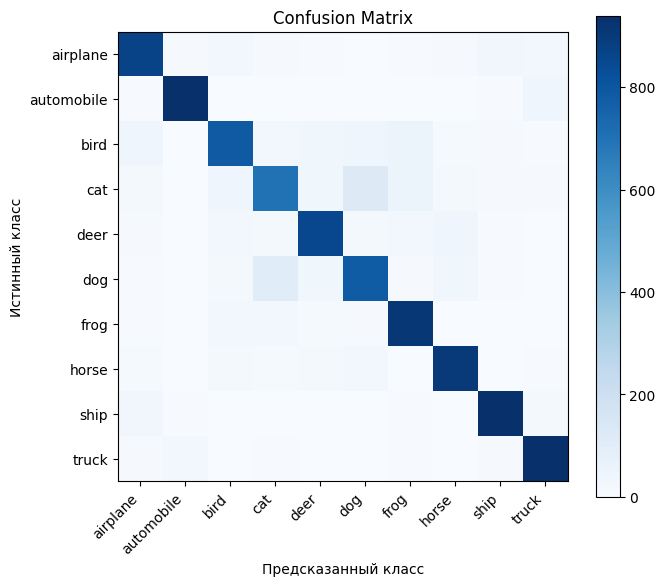

In [17]:
def plot_confusion_matrix(targets, preds):
    targets_np = targets.numpy() if isinstance(targets, torch.Tensor) else np.asarray(targets)
    preds_np = preds.numpy() if isinstance(preds, torch.Tensor) else np.asarray(preds)

    if SKLEARN_AVAILABLE:
        cm = confusion_matrix(targets_np, preds_np, labels=list(range(NUM_CLASSES)))
    else:
        cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
        for t, p in zip(targets_np, preds_np):
            cm[t, p] += 1

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Предсказанный класс")
    ax.set_ylabel("Истинный класс")
    ax.set_title("Confusion Matrix")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(test_targets, test_preds)


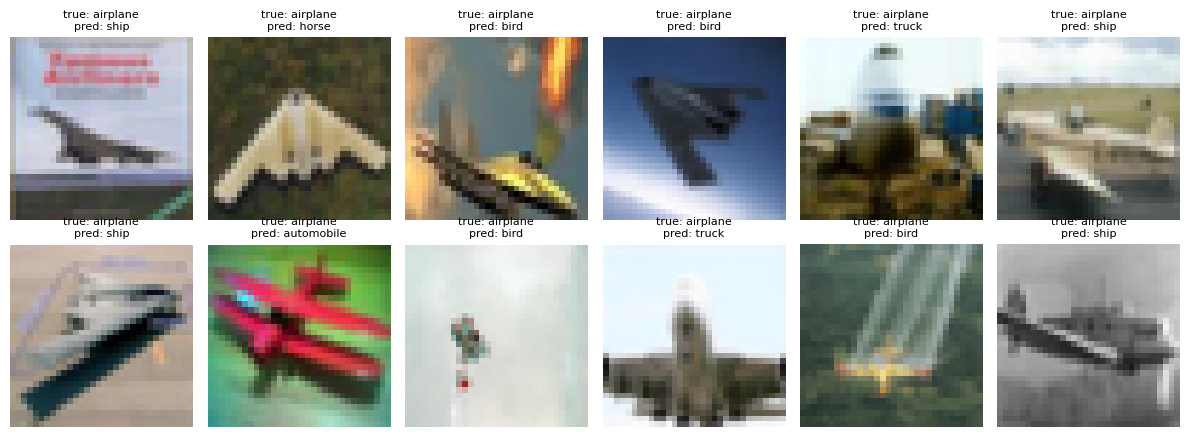

In [18]:
def show_mistakes(images, targets, preds, n=12):
    targets_np = targets.numpy() if isinstance(targets, torch.Tensor) else np.asarray(targets)
    preds_np = preds.numpy() if isinstance(preds, torch.Tensor) else np.asarray(preds)

    mistake_indices = np.where(targets_np != preds_np)[0]
    if len(mistake_indices) == 0:
        print("Ошибок не найдено.")
        return

    chosen = mistake_indices[:n]
    images_to_show = denormalize(images[chosen]).clamp(0, 1)

    cols = min(len(chosen), 6)
    rows = int(np.ceil(len(chosen) / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(2 * cols, 2.2 * rows))
    axs = np.array(axs).reshape(-1)

    for ax, idx, image in zip(axs, chosen, images_to_show):
        ax.imshow(image.permute(1, 2, 0))
        true_name = CLASS_NAMES[int(targets_np[idx])]
        pred_name = CLASS_NAMES[int(preds_np[idx])]
        ax.set_title(f"true: {true_name}\npred: {pred_name}", fontsize=8)
        ax.axis("off")

    for ax in axs[len(chosen):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_mistakes(test_images, test_targets, test_preds, n=12)


# 8. Отчет

Заполните этот раздел после всех экспериментов (вставьте свои реальные числа и наблюдения).

## Железо и настройки обучения

- Устройство: `print(device)` в начале ноутбука покажет `cuda` или `cpu` — впишите то, что видите у себя.
- Число эпох на эксперимент: 10-12 (см. `epochs` в конфигах `baseline_config`, `improved_config`, `experiments`).
- Примерное время обучения: возьмите `elapsed_sec` из `all_summaries[<name>]["elapsed_sec"]` для каждого эксперимента.

## Анализ

Ответьте на вопросы ниже, опираясь на `print_results_table(all_summaries)`, графики `plot_history` и confusion matrix:

1. **Какое изменение сильнее всего улучшило validation accuracy?**
   Сравните `best_val_accuracy` в таблице результатов между `exp_control` и остальными `exp_*`, а также `baseline` vs `improved_cnn`.

2. **Какое изменение ухудшило качество или не помогло?**
   Обратите внимание на `exp_scheduler_none` (обучение без scheduler) и `exp_optimizer_sgd` (SGD с тем же lr, что и Adam, может недообучиться — Adam обычно сходится быстрее при lr=1e-3, тогда как SGD часто требует lr на порядок выше).

3. **Наблюдали ли вы overfitting?**
   Посмотрите на графики `plot_history`: если `train_accuracy` продолжает расти, а `val_accuracy` выходит на плато или падает, а `val_loss` растет при падающем `train_loss` — это признак переобучения.

4. **Какие классы оказались самыми сложными для модели?**
   Используйте вывод `per_class_accuracy` и `plot_confusion_matrix`. Для CIFAR-10 типично, что визуально похожие классы животных (`cat`/`dog`, `deer`/`horse`) путаются чаще, чем явно непохожие (`airplane`/`truck`).

5. **Что бы вы попробовали дальше, если бы у вас было больше compute?**
   Например: более глубокую ResNet-подобную архитектуру, mixup/cutmix аугментации, label smoothing, более длинное обучение с warmup, поиск гиперпараметров (learning rate, weight decay) по сетке.

## Итоговый вывод

Лучший результат на валидационной (86.1%) и тестовой (86.2%) выборках показала улучшенная ResNet-подобная модель с оптимизатором Adam, косинусным планировщиком и weight decay. Переход к более глубокой архитектуре с residual-связями дал основной прирост качества. Эксперимент с SGD подтвердил, что для выбранного lr Adam подходит лучше. Модель не переобучается благодаря регуляризации, но по-прежнему испытывает трудности с визуально схожими классами. Основным ограничением эксперимента было ограниченное число эпох и вычислительных ресурсов (CPU). При большем бюджете времени можно было бы улучшить результат за счет дальнейшего усложнения модели и подбора гиперпараметров.
